# **WELL LOG PREDICTIVE MODELLING PROJECT**

## **Objective** 
The aim of this project is to perform data loading, cleaning, visualization, quality control, and simple predictive modelling of a subsurface property using the Data2.las LAS well log dataset.

## **DATASET OVERVIEW**


### **Data Set Information**
The dataset consists of 23,064 instances (depth samples) representing geophysical measurements from a single borehole. The logs provide a continuous record of the physical properties of the rock formations and the fluids they contain.
**Total Samples:** 23,064 depth points.

**Vertical Coverage:** Data spans from the top of the logged interval to the total depth, typically sampled at 0.5ft (0.1524m) increments.

**Data Quality Note:** Approximately 33% of the dataset contains null values for DT, RESD, LLS, and NPHI curves, which might likely represent the upper "top-hole" section where only basic correlation logs were run.


### **Attribute Information**

- **DEPT (Depth):** The vertical distance from a reference point (usually the rig floor) to the measurement point, measured in meters or feet.

- **CALI (Caliper):** Measures the diameter of the borehole. Used to identify "washouts" (where the hole is wider than the drill bit) or "filter cakes" (where the hole is narrower).

- **GR (Gamma Ray):** Measures natural radioactivity. Used to differentiate between shales (high radioactivity) and reservoir rocks like sandstones or carbonates (low radioactivity).

- **RESD (Deep Resistivity):** Measures the ability of the formation to resist electrical current. High resistivity often indicates hydrocarbons (oil/gas) or low-porosity rock, while low resistivity indicates brine-saturated (salty water) zones.

- **LLS (Shallow Resistivity):** Similar to RESD but measures closer to the borehole wall. The difference between LLS and RESD helps identify invasion, where drilling fluid has pushed into the rock.

- **DT (Sonic/Delta-T):** Measures the travel time of sound waves through the rock. It is a primary indicator of lithology and porosity.

- **NPHI (Neutron Porosity):** Measures the hydrogen index in the formation. In clean zones, this represents pore volume filled with water or oil.

- **RHOB (Bulk Density):** Measures the mass of the rock per unit volume. It is used to calculate porosity and identify the mineral composition of the matrix.

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ==========================================================================================

### **STEP 1:** Load the provided LAS file using lasio

In [1]:
## Import the necessary dependencies
import lasio as ls  ## For reading well log dataset
import pandas as pd  ## For Data Wrangling
import numpy as np  ## For Mathematical computation

## Visualization
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

In [2]:
las = ls.read("Data2.las")

#### **STEP 3:** Convert it to a Pandas DataFrame

In [3]:
data = las.df().reset_index()

#### **STEP 4:** Handle null values using las.well.NULL.value

In [4]:
NULL_VALUES = las.well.NULL.value
data.replace(NULL_VALUES, np.nan, inplace = True)

#### **STEP 5:** Display metadata and curve information

In [5]:
## Checking the well details
print(las.well)

Mnemonic  Unit  Value                                                      Description      
--------  ----  -----                                                      -----------      
STRT      ft    10.0                                                                        
STOP      ft    11541.5                                                                     
STEP      ft    0.5                                                                         
NULL            -999.25                                                                     
COMP                                                                       COMPANY          
WELL            Test-04                                                    WELL             
FLD                                                                        FIELD            
LOC                                                                        LOCATION         
SRVC                                                                  

In [6]:
## Check the well items
well_items = las.well.items()
for key, val in well_items:
    print(f"{key} : {val.value}")

STRT : 10.0
STOP : 11541.5
STEP : 0.5
NULL : -999.25
COMP : 
WELL : Test-04
FLD : 
LOC : 
SRVC : 
DATE : 2025-01-17 10:21:47   : Log Export Date {yyyy-MM-dd HH:mm
PROV : 
UWI : 
API : 


In [7]:
## Check other well parameters
print(las.params)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  


In [8]:
## Inspecting the curves
print(f"WELL CURVES: \n{las.curves}")

WELL CURVES: 
Mnemonic  Unit     Value  Description  
--------  ----     -----  -----------  
DEPT      ft              DEPTH        
CALI      in              CALI         
DT        us/ft           DT           
GR        gAPI            GR           
RESD      ohm.m           RESD         
LLS       ohm.m           LLS          
NPHI      ft3/ft3         NPHI         
RHOB      g/cm3           RHOB         


#### **STEP 6:** Exploratory Data Analysis

In [9]:
## Check the columns
data.columns

Index(['DEPT', 'CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI', 'RHOB'], dtype='object')

In [10]:
### Peruse the first five rows of the dataset
data.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
1,10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
2,11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
3,11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
4,12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


In [11]:
### Peruse the last five rows of the dataset
data.tail()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
23059,11539.5,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN
23060,11540.0,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN
23061,11540.5,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN
23062,11541.0,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN
23063,11541.5,NaN,94.099998,108.132896,3.2859,2.9703,-9.9925,NaN


In [12]:
## Check the shape of the dataset (Number of Rows and Columns)
data_shape = data.shape
print(f"Number of rows in the dataset: {data_shape[0]}")
print(f"Number of columns in the dataset: {data_shape[1]}")

Number of rows in the dataset: 23064
Number of columns in the dataset: 8


In [13]:
## Checking the data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23064 entries, 0 to 23063
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPT    23064 non-null  float64
 1   CALI    23021 non-null  float64
 2   DT      15309 non-null  float64
 3   GR      23064 non-null  float64
 4   RESD    15309 non-null  float64
 5   LLS     15309 non-null  float64
 6   NPHI    15309 non-null  float64
 7   RHOB    15181 non-null  float64
dtypes: float64(8)
memory usage: 1.4 MB


In [14]:
## Check for duplicated values
data.duplicated().sum()

0

In [15]:
## summary statistics to know the mean, std, min, max, quartiles
data.describe().T

,count,mean,std,min,25%,50%,75%,max
DEPT,23064.0,5775.750000,3329.073820,10.000000,2892.875000,5775.750000,8658.625000,11541.500000
CALI,23021.0,16.735029,3.845561,5.723400,12.727201,17.199999,19.799999,22.777199
DT,15309.0,114.785571,26.251967,13.900001,97.900002,110.599998,121.399994,260.700012
GR,23064.0,42.331518,26.903011,0.600000,19.365000,37.418850,55.589650,142.199493
RESD,15309.0,30.637322,50.863012,0.053700,1.744100,5.521200,44.506100,1213.057373
LLS,15309.0,5.782516,12.707649,0.091400,1.800200,3.529800,6.457200,341.103912
NPHI,15309.0,0.226503,0.957280,-9.992500,0.271100,0.316100,0.369200,0.626800
RHOB,15181.0,2.182348,0.152106,1.266900,2.142600,2.196800,2.254300,2.671600


#### *Check for Missing Values*

In [16]:
## Check for Missing Values
data.isnull().sum()

DEPT       0
CALI      43
DT      7755
GR         0
RESD    7755
LLS     7755
NPHI    7755
RHOB    7883
dtype: int64

In [17]:
## Check the percentage of Missing Values in each column
((data.isnull().sum() / len(data)) * 100)

DEPT     0.000000
CALI     0.186438
DT      33.623829
GR       0.000000
RESD    33.623829
LLS     33.623829
NPHI    33.623829
RHOB    34.178807
dtype: float64

In [18]:
## Check the percentage of Missing Values in dataset
data.isnull().values.mean() * 100

21.107570239334027

In [19]:
## Check records without missing values in the target variable
data[~data["RESD"].isnull()]

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
7755,3887.5,19.199999,69.300003,13.573300,51.417099,28.012100,-9.9925,NaN
7756,3888.0,19.150000,69.300003,13.341700,60.520000,48.122700,-9.9925,NaN
7757,3888.5,19.000000,69.300003,13.689200,60.520000,38.912800,-9.9925,NaN
7758,3889.0,18.900000,69.300003,13.341700,60.520000,23.816401,-9.9925,NaN
7759,3889.5,19.000000,69.300003,14.152500,34.631500,97.107903,-9.9925,NaN
...,...,...,...,...,...,...,...,...
23059,11539.5,NaN,94.099998,108.132896,3.285900,2.970300,-9.9925,NaN
23060,11540.0,NaN,94.099998,108.132896,3.285900,2.970300,-9.9925,NaN
23061,11540.5,NaN,94.099998,108.132896,3.285900,2.970300,-9.9925,NaN
23062,11541.0,NaN,94.099998,108.132896,3.285900,2.970300,-9.9925,NaN


In [20]:
## Checking the unique values
data["RESD"].unique()

array([        nan, 51.417099  , 60.52000046, ...,  3.33089995,
        3.3441999 ,  3.28590012])

In [21]:
## Checking the percentage of values counts
data["NPHI"].value_counts(normalize = True)*100

NPHI
-9.9925    0.836109
-2.0158    0.411523
-2.0157    0.143706
 0.3379    0.111046
 0.2807    0.111046
             ...   
 0.5660    0.006532
 0.0735    0.006532
 0.1786    0.006532
 0.1938    0.006532
 0.5269    0.006532
Name: proportion, Length: 3178, dtype: float64

#### **STEP 7:** Plot at least 3 well log curves against depth

##### *Data Cleaning / Feature Engineering*

In [22]:
# ===========================================================================
## Remove anormalous values from the dataset using defined industry ranges.
ranges = {
    "CALI": (6, 20),
    "DT": (40, 240),
    "GR": (0, 150),
    "RESD": (0.2, 2000),
    "LLS": (0.2, 2000),
    "NPHI": (-0.15, 0.45),
    "RHOB": (1.95, 2.95)
}

# ===========================================================================
## Make a copy of the data
df = data.copy()
 
# ===========================================================================
## Filter the dataset and change the out of range values to Null values
for col, (min, max) in ranges.items():
    if col in df.columns:
        mask = df[col].notna() & ((df[col] < min) | (df[col] > max))
        out_of_range_sum = int(mask.sum())
        print(col,"Out of range Value:", out_of_range_sum)
        df.loc[mask, col] = np.nan


CALI Out of range Value: 5415
DT Out of range Value: 35
GR Out of range Value: 0
RESD Out of range Value: 82
LLS Out of range Value: 76
NPHI Out of range Value: 1239
RHOB Out of range Value: 773


In [23]:
data.isnull().sum()

DEPT       0
CALI      43
DT      7755
GR         0
RESD    7755
LLS     7755
NPHI    7755
RHOB    7883
dtype: int64

In [24]:
df.isnull().sum()

DEPT       0
CALI    5458
DT      7790
GR         0
RESD    7837
LLS     7831
NPHI    8994
RHOB    8656
dtype: int64

In [25]:
# ===========================================================================
## Define the target Variable, independent features, and drop the Null Values
target = "RESD"
dept_col = "DEPT"
features = ["CALI", "DT", "GR", "LLS", "NPHI", "RHOB"]

# ===========================================================================
## Concatanate the dataframe with the two columns
model_df = df[features + [dept_col, target]].copy()

# ===========================================================================
## Drop Null Values
cleaned_df = model_df.dropna(subset = features + [target]).copy()

cleaned_df.head()

,CALI,DT,GR,LLS,NPHI,RHOB,DEPT,RESD
7964,19.15,57.399998,23.571100,2.3469,0.3883,2.0429,3992.0,1.3630
7965,19.10,67.599998,25.473600,1.9242,0.4387,2.0511,3992.5,0.8341
7974,19.50,162.699997,35.584202,0.6135,0.3250,2.1017,3997.0,0.2101
7975,19.60,163.000000,36.689899,3.9638,0.2839,2.1919,3997.5,60.5200
7976,19.35,164.700012,37.687599,2.0985,0.2784,2.1709,3998.0,60.5200


In [26]:
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CALI,12820.0,13.986059,2.359935,10.380400,12.030725,13.009700,15.700924,19.995699
DT,12820.0,111.521817,20.625916,42.300003,97.400002,108.199997,118.700005,216.300003
GR,12820.0,55.532060,23.230404,22.760401,36.609699,44.802599,76.694826,142.199493
LLS,12820.0,5.571975,12.658808,0.613500,1.531650,3.326550,6.766700,341.103912
NPHI,12820.0,0.310493,0.058257,0.001400,0.268100,0.307500,0.350200,0.450000
RHOB,12820.0,2.216966,0.085369,1.950400,2.159000,2.206400,2.263725,2.671600
DEPT,12820.0,8000.784204,2109.143933,3992.000000,6357.375000,8107.250000,9821.625000,11477.000000
RESD,12820.0,25.639164,49.240023,0.210100,1.537825,3.625450,32.696949,1213.057373


##### *Performing Basic Plots*

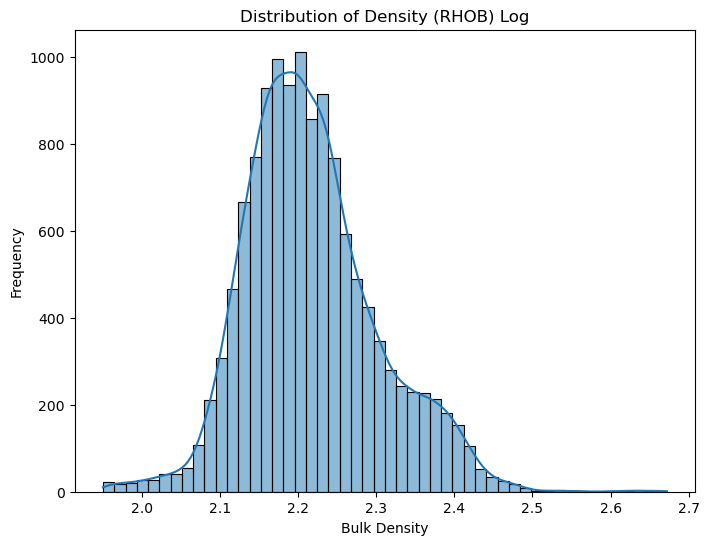

In [27]:
## Check the distribution of the curves using histogram
plt.figure(figsize = (8, 6))
sns.histplot(cleaned_df["RHOB"], bins = 50, kde = True)
plt.title("Distribution of Density (RHOB) Log")
plt.xlabel("Bulk Density")
plt.ylabel("Frequency")
plt.show()

*From the histogram, the highest frequency of data points (which is the mode) occurs around 2.15 – 2.25 g/cm³.*

*In typical sedimentary basins, this range is a characteristic of porous sandstones or moderately compacted shales.*

*The matrix density of the sand is given as $2.65$ $g/cm^3$ while that of water is given as $1.0$ $g/cm^3$, a reading of $2.2$ $g/cm^3$ directly suggests a rock with significant porosity (roughly $25-30\%$).2.*

*The "Tail" Towards Higher Density: The graph shows a smaller tail extending toward 2.4 – 2.5 g/cm³. This indicates deeper or more compacted sections of the well, meaning; as we go deeper, the weight of overlying rocks squeezes the pores, which increases the density. Alternatively, this could represent tight (low porosity) limestone or well-cemented siltstones.*

<Axes: ylabel='RHOB'>

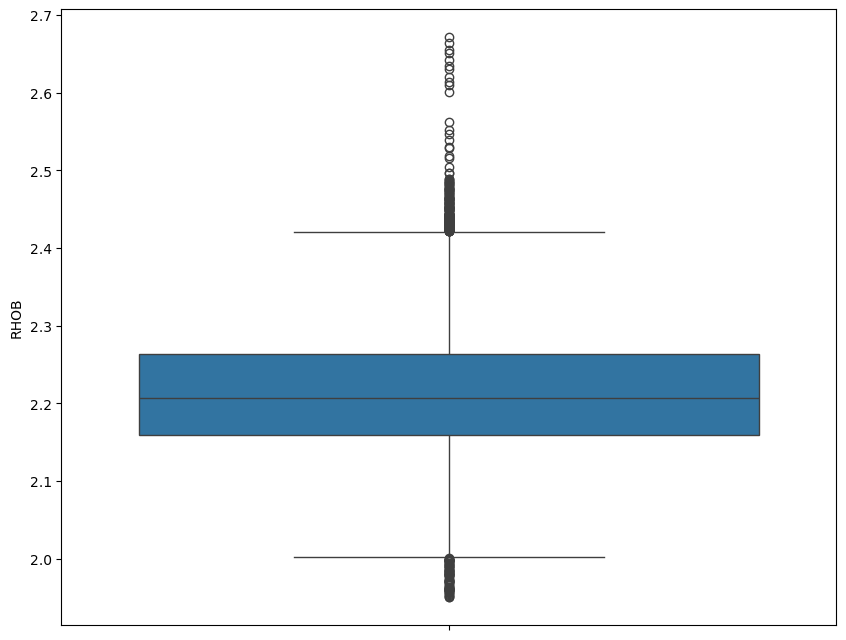

In [28]:
## Check for outliers using boxplot
plt.figure(figsize = (10, 8))
sns.boxplot(cleaned_df["RHOB"])

In [29]:
data["RHOB"].describe()

count    15181.000000
mean         2.182348
std          0.152106
min          1.266900
25%          2.142600
50%          2.196800
75%          2.254300
max          2.671600
Name: RHOB, dtype: float64

In [30]:
Q_1 = np.nanpercentile(cleaned_df["RHOB"], 25)
Q_3 = np.nanpercentile(cleaned_df["RHOB"], 75)
IQR = Q_3 - Q_1

lower_bound = Q_1 - 1.5 * IQR
upper_bound = Q_3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)



2.0019122362249995
2.420812726025


In [31]:
## Outlier detection and removal using IQR Method
def iqr_outlier_detection(dataset, col, output_col = None):
    df = dataset.copy()

    # ========================================================================
    ## Calculate the Q1, Q2, and IQR
    Q_1 = df[col].quantile(0.25)
    Q_3 = df[col].quantile(0.75)
    IQR = Q_3 - Q_1

    # ========================================================================
    # Calculate the lower and upper bounds
    lower_bound = Q_1 - 1.5 * IQR
    upper_bound = Q_3 + 1.5 * IQR

    # ========================================================================
    ## Define the output column
    if output_col is None:
        output_col = f"{col}_outlier"

    # ========================================================================
    ## filter the dataframe
    clean_data = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return clean_data


outlier = iqr_outlier_detection(dataset = cleaned_df, col = "RHOB")

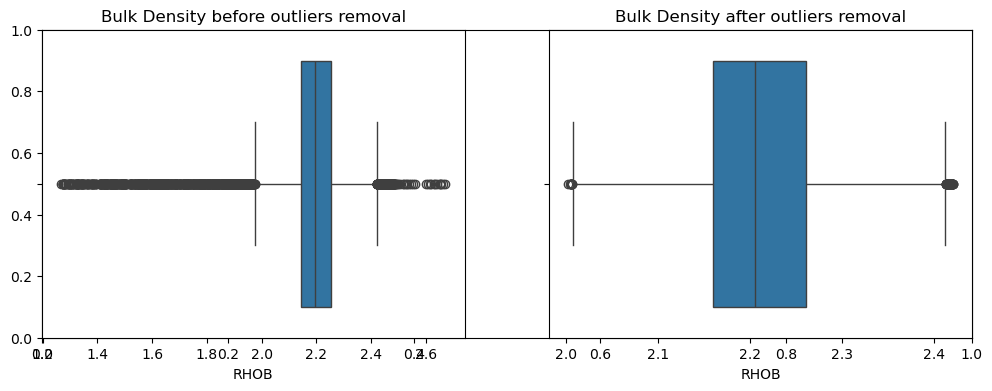

In [32]:
# ===============================================
## Check outlier before and after Outliers removal
# ===============================================
plt.subplots(figsize = (12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data["RHOB"], orient = "y")
plt.title("Bulk Density before outliers removal")
plt.subplot(1, 2, 2)
sns.boxplot(outlier["RHOB"], orient = "y")
plt.title("Bulk Density after outliers removal")
plt.show()

*- The leftward plot shows noticeable outliers above $2.5$ $g/cm^3$ and below $2.0$ $g/cm^3$, which could likely represent borehole irregularities or tool noise.*

*- This might not have any negative impact on the dataset since it was initaially constrained to the physical range of sedimentary rocks (from $1.95 - 2.95$ $g/cm^3$) to further remove anormalous values. This narrowed the variance to ensure that the subsequent Linear Regression model for Resistivity (RESD) is trained on the true bulk density of the formation rather than measurement artifacts.*

In [33]:
data.head(1)

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


base_case_cutoff: 44.80


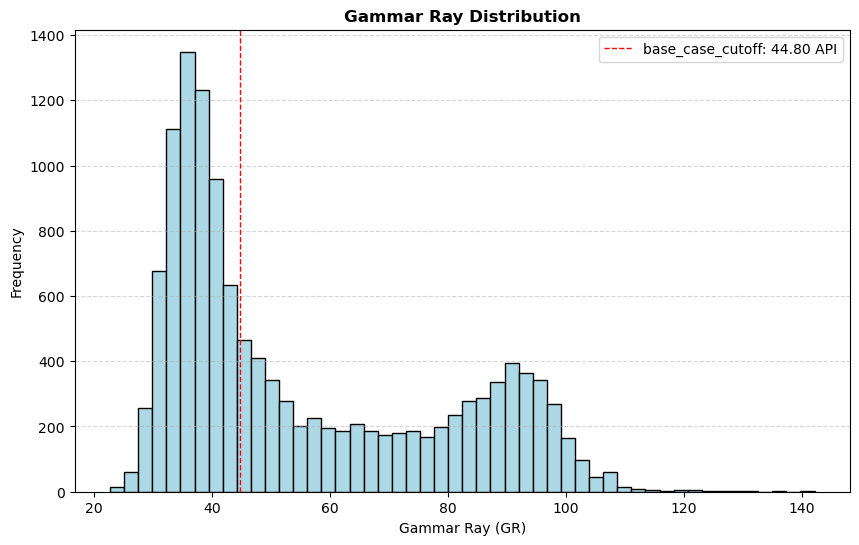

In [34]:
# Calculation the GR_cutoff, Using 50th percntile
base_case_cutoff = np.percentile(cleaned_df["GR"], 50)
base_case_cutoff

plt.figure(figsize = (10, 6))

plt.hist(cleaned_df["GR"], bins = 50, edgecolor = "black", color = "lightblue")
plt.axvline(base_case_cutoff, 
            color = "red",
            ls = "--",
            lw = 1,
            label = f"base_case_cutoff: {base_case_cutoff:.2f} API"
            )
plt.title("Gammar Ray Distribution", weight = "bold")
plt.xlabel("Gammar Ray (GR)")
plt.ylabel("Frequency")
plt.grid(axis = "y", alpha = 0.5, ls = "--")
plt.legend()
plt.plot()

print(f"base_case_cutoff: {base_case_cutoff:.2f}")

*The Left Peak (~35 API): Clean Sandstone*
*The large peak on the left side of the plot represents "Clean" formation. Because Gamma Ray measures radioactivity, so low API values indicate a lack of redioactive minerals.*
*This is likely a porous sandstone or carbonate, which are the primary targets for fluid flow and hydrocarbon storage.*

*The Right Peak (~90 API): Shale or Clay*
*The smaller peak on the right side of the plot represents Shale. Shales are known to compose of fine-grained clay minerals that are naturally more radioactive. These zones act as "seals" or barriers to fluid flow.*

*At 44.80 API, the "base_case_cutoff" is cutting right into the "Sand" peak, which might classify a lot of the good reservoir rock as "shale". It is too conservative.*

*A geological cutoff of 60 API is selected to better encompass the reservoir's transition zones and ensure that 'shaly-sands' with potential storage capacity were not erroneously classified as non-reservoir shale.*

In [35]:
gr_cutoff = 60

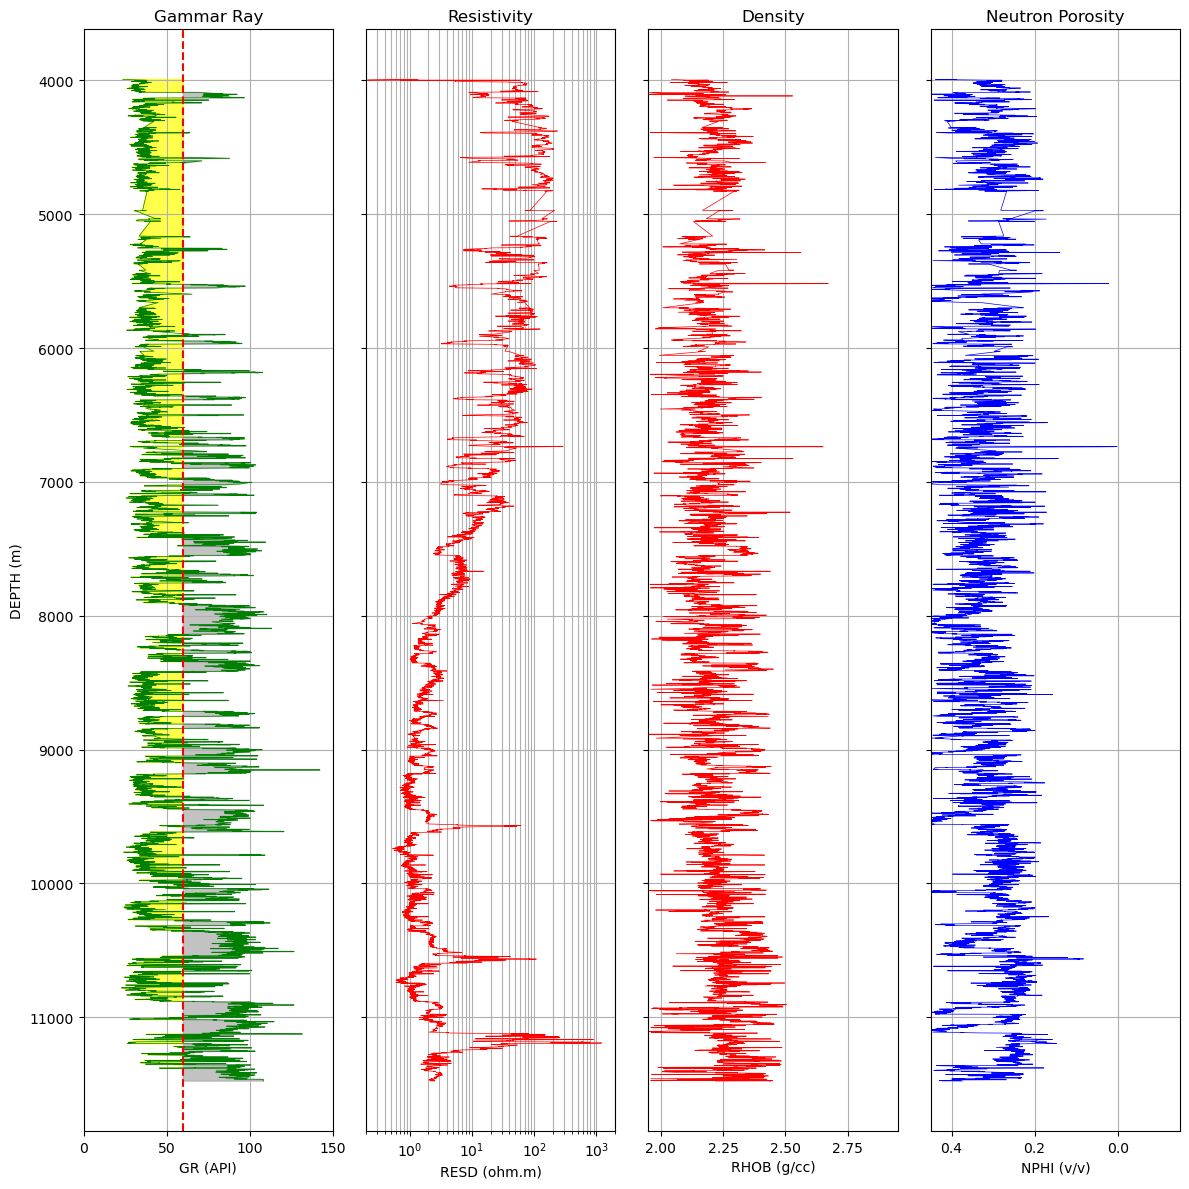

In [36]:
fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (12, 12), sharey = True)

# ===============================================================
## Track 1: Gammar Ray (GR)
# ===============================================================
ax[0].plot(cleaned_df["GR"], cleaned_df["DEPT"], color = "green", lw = 0.5)
ax[0].axvline(x = gr_cutoff, color = "r", ls = "--", lw = "1.5")
ax[0].fill_betweenx(cleaned_df["DEPT"],
                    gr_cutoff, 
                    cleaned_df["GR"], 
                    where = (cleaned_df["GR"] <= gr_cutoff), 
                    color = "yellow",
                    alpha = 0.7
                    )
ax[0].fill_betweenx(cleaned_df["DEPT"],
                    gr_cutoff, 
                    cleaned_df["GR"], 
                    where = (cleaned_df["GR"] >= gr_cutoff), 
                    color = "darkgrey",
                    alpha = 0.7
                    )
ax[0].set_xlim(0, 150)
ax[0].set_title("Gammar Ray")
ax[0].set_xlabel("GR (API)")
ax[0].grid()

# ===============================================================
## Track 2: Resistivity (RESD)
# ===============================================================
ax[1].plot(cleaned_df["RESD"], cleaned_df["DEPT"], color = "red", lw = 0.5)
ax[1].set_xlim(0.2, 2000)
ax[1].set_xscale("log")
ax[1].set_title("Resistivity")
ax[1].set_xlabel("RESD (ohm.m)")
ax[1].grid(True, which="both")

# ===============================================================
## Track 3: Density (RHOB)
# ===============================================================
ax[2].plot(cleaned_df["RHOB"], cleaned_df["DEPT"], color = "red", lw = 0.5)
ax[2].set_xlim(1.95, 2.95)
ax[2].set_title("Density")
ax[2].set_xlabel("RHOB (g/cc)")
ax[2].grid()

# ===============================================================
## Track 4: Neutron Porosity (NPHI)
# ===============================================================
ax[3].plot(cleaned_df["NPHI"], cleaned_df["DEPT"], color = "blue", lw = 0.5)
ax[3].set_xlim(0.45, -0.15) # It uses reverse scale
ax[3].set_title("Neutron Porosity")
ax[3].set_xlabel("NPHI (v/v)")
ax[3].grid(True)


# =====================================
# Set Depth column
# =====================================
ax[0].set_ylabel("DEPTH (m)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Track 1:**
*- Gamma Ray: The 60 API cutoff clearly separates the section into two main lithologies.*

*The Yellow Zones (Sands): These indicate clean, potential reservoir rocks.*

*The Grey Zones (Shales): These are the "non-reservoir" sections. The increased frequency of grey zones above 8,000m suggests a transition into a more shale-dominated environment.*

**Track 2:**
*- Resistivity (Fluid & Saturation)This track is on a logarithmic scale.* 

*There is a high Resistivity Spikes at the interval around 11,200m. Even though the GR is fluctuating, the resistivity peaks sharply (>100 ohm.m). This is a classic signature of hydrocarbons (oil or gas) or a very tight, non-porous rock.*

*In the lower sections (4,000m – 7,000m), the resistivity stays relatively low (1 - 10 ohm.m). This likely represents brine-saturated (saltwater) sands.*

**Tracks 3 and 4:**
*- Porosity (Density & Neutron): These tools work together to define how much "space" is in the rock.*

*- Density (RHOB): Higher values (moving right) indicate denser rock and it seems quite stable, which suggests a consistent mineralogy.*

*- Neutron Porosity (NPHI): This is usually plotted "backwards" (high values on the left)."Crossover": When the Density curve (Track 3) moves left and the Neutron curve (Track 4) moves right, they "cross over." This is a primary indicator of Gas Zones.*

# ===================================

#### **STEP 8:** Generate a correlation heatmap

In [37]:
## Check the relationship between curves
correlation = cleaned_df.corr()
correlation

,CALI,DT,GR,LLS,NPHI,RHOB,DEPT,RESD
CALI,1.000000,0.640214,-0.386783,0.029303,0.252422,-0.281736,-0.724093,0.456201
DT,0.640214,1.000000,-0.286035,0.022350,0.182198,-0.269870,-0.852418,0.458637
GR,-0.386783,-0.286035,1.000000,-0.102190,0.392278,0.468081,0.389693,-0.345667
LLS,0.029303,0.022350,-0.102190,1.000000,-0.179574,0.015773,-0.044770,0.687969
NPHI,0.252422,0.182198,0.392278,-0.179574,1.000000,-0.231515,-0.157385,-0.187804
RHOB,-0.281736,-0.269870,0.468081,0.015773,-0.231515,1.000000,0.268460,-0.031460
DEPT,-0.724093,-0.852418,0.389693,-0.044770,-0.157385,0.268460,1.000000,-0.494238
RESD,0.456201,0.458637,-0.345667,0.687969,-0.187804,-0.031460,-0.494238,1.000000


Text(0.5, 1.0, 'CORRELATION HEATMAP')

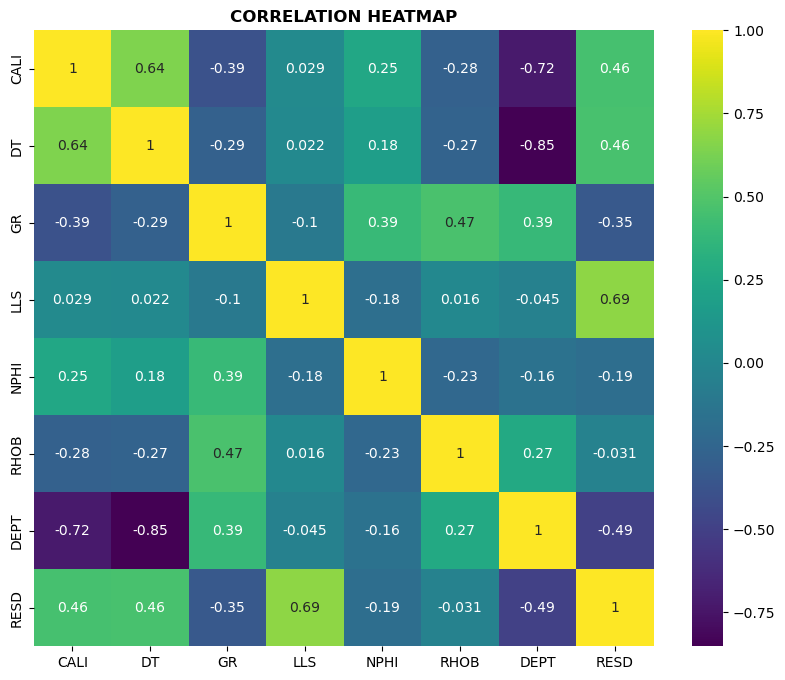

In [38]:
## Plot correlation heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(correlation, annot = True, cmap = "viridis")
plt.title("CORRELATION HEATMAP", weight = "bold")

*The LLS (Shallow Resistivity) shows the strongest positive correlation of 0.69. Tnis might be as result of both logs measuring the same physical property at different borehole depths.*

*DEPT with -0.49 and DT with 0.46 follow, suggesting that compaction and pore-fluid velocity significantly influence resistivity.*

*In contrast, GR with -0.35 shows a negative relationship, reflecting the contrast between conductive, radioactive shales and more resistive, clean sandstones.*

# ===================================

#### **STEP 9:** Build a Linear Regression model to predict RESD

In [39]:
cleaned_df.head(2)

,CALI,DT,GR,LLS,NPHI,RHOB,DEPT,RESD
7964,19.15,57.399998,23.5711,2.3469,0.3883,2.0429,3992.0,1.3630
7965,19.10,67.599998,25.4736,1.9242,0.4387,2.0511,3992.5,0.8341


In [40]:
cleaned_df.shape

(12820, 8)

In [41]:
# ============================================================
## Divide the dataset into independent and dependend variables
# ============================================================
X = cleaned_df.iloc[:, : -1]
y = cleaned_df.iloc[:, -1]


# ============================================================================================
## Split the independent and dependent variables into trainset and testset using train_test_split
# ============================================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

print("X_train Size:", X_train.shape)
print("X_test Size:", X_test.shape)
print("y_train Size:", y_train.shape)
print("y_test Size:", y_test.shape)


X_train Size: (9615, 7)
X_test Size: (3205, 7)
y_train Size: (9615,)
y_test Size: (3205,)


In [42]:
y_train

14942      3.892800
12490     15.332200
10874     96.408897
20956      3.936600
9521     159.108597
            ...    
22005      1.771900
14872      5.996200
15071      2.707000
8982      92.561996
17099      1.843600
Name: RESD, Length: 9615, dtype: float64

##### *Data Transformation*

In [43]:
# =============================
## Standardize the data
# =============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================
## Initialize the model
# ==============================================
lin_reg_model = LinearRegression()

In [44]:
X_train_scaled

array([[-0.58420945,  0.01556383,  1.63948529, ...,  0.92681059,
         1.01323443, -0.25266893],
       [ 0.32219449,  0.17155364,  0.85567583, ...,  1.38399875,
         0.68275073, -0.83415589],
       [ 1.90735103,  0.58590098, -0.84464264, ..., -0.64434677,
         0.48773308, -1.21738711],
       ...,
       [-0.38814721,  0.35191682,  1.80085835, ...,  1.616005  ,
         1.39860339, -0.22207683],
       [ 2.31138894,  3.35959014, -0.50530373, ..., -0.00803618,
        -0.04360956, -1.66607118],
       [-0.57611039, -0.26229247, -0.85082869, ..., -0.8302925 ,
        -1.38889837,  0.25885937]])

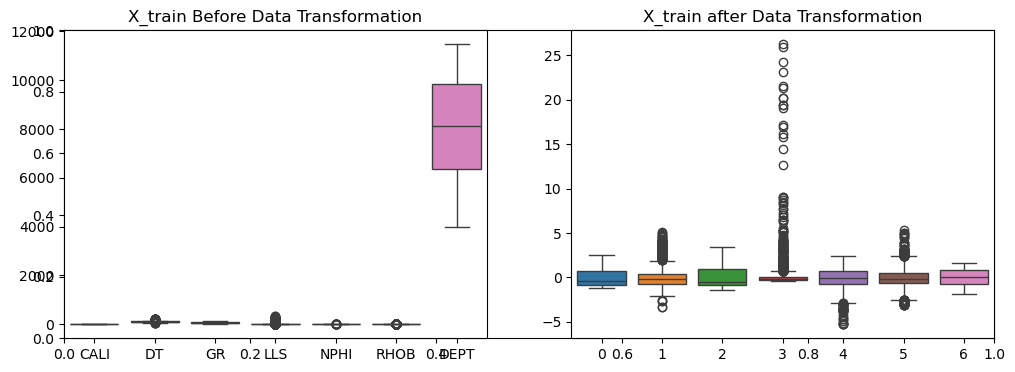

In [45]:
# =============================================
## Check Scaled versus unscaled data
# =============================================
plt.subplots(figsize = (12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(X_train)
plt.title("X_train Before Data Transformation")
plt.subplot(1, 2, 2)
sns.boxplot(X_train_scaled)
plt.title("X_train after Data Transformation")
plt.show()

##### *Model Training and Prediction*

In [46]:
# ===========================
## Training the Linear Model
# ===========================
model = lin_reg_model.fit(X_train_scaled, y_train)

# =============================================
## Prediction
# =============================================
y_pred = model.predict(X_test_scaled)


In [47]:
print(f"Model Coefficient or Slope: \n{model.coef_}")
print("======="*10)
print(f"Model Intercept: \n{model.intercept_}")
print("======="*10)
print(f"Predicted Values: \n {y_pred}")

Model Coefficient or Slope: 
[12.14585528 10.88206383 -4.43976877 32.67225871 -6.30736894  6.78357055
 -6.0840063 ]
Model Intercept: 
25.733476411595472
Predicted Values: 
 [ 7.90449122 54.28108642 13.19603243 ... 60.54481469 10.68644753
  2.71638269]


#### **STEP 10:** Evaluate the model using MAE, RMSE, and R²

In [48]:
# =================================================
## Evaluate the model using MAE, RMSE, and R2_score
# =================================================
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Scoring Metric (R²): {score}")

Mean Absolute Error: 15.803276188874555
Root Mean Squared Error: 23.43617088839433
Scoring Metric (R²): 0.7351935873459838


# ====================================

#### **STEP 11:** Plot actual vs predicted resistivity

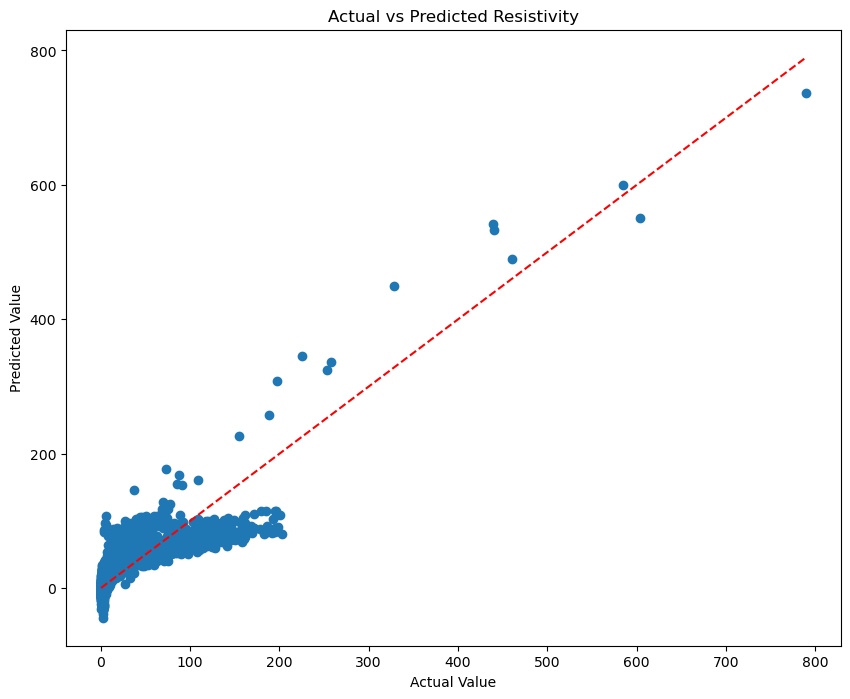

In [49]:
plt.figure(figsize = (10, 8))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "r", ls = "--")
plt.title("Actual vs Predicted Resistivity")
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.show()

*The model achieved an $R^2$ of 0.73, indicating good predictive performance overall. While reliable for identifying general trends, the MAE of 15.8 suggests some deviations, particularly in high-resistivity zones where the relationship becomes non-linear.*

*The actual vs predicted plot shows that the model performs well for low to moderate resistivity values but tends to underestimate high resistivity zones. This suggests a bias due to data imbalance, where high-resistivity (potential hydrocarbon-bearing) intervals are underrepresented, leading to reduced accuracy in those critical regions.*


### **Model Optimization**

In [50]:
# ==============================================================================================================
## The target variable needs to be transformed using log transform, since Resistivity is usually log-distributed
# ==============================================================================================================


# ============================================================
## Divide the dataset into independent and dependend variables
# ============================================================
X = cleaned_df.iloc[:, : -1]
target = cleaned_df.iloc[:, -1]

y = np.log1p(y)

# ============================================================================================
## Split the independent and dependent variables into trainset and testset using train_test_split
# ============================================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

print("X_train Size:", X_train.shape)
print("X_test Size:", X_test.shape)
print("y_train Size:", y_train.shape)
print("y_test Size:", y_test.shape)


X_train Size: (9615, 7)
X_test Size: (3205, 7)
y_train Size: (9615,)
y_test Size: (3205,)


In [51]:
# =============================
## Standardize the data
# =============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================
## Initialize the model
# ==============================================
lin_reg_model = LinearRegression()

In [52]:
# ===========================
## Training the Linear Model
# ===========================
model = lin_reg_model.fit(X_train_scaled, y_train)

# =============================================
## Prediction
# =============================================
y_pred = model.predict(X_test_scaled)

In [53]:
print(f"Model Coefficient or Slope: \n{model.coef_}")
print("======="*10)
print(f"Model Intercept: \n{model.intercept_}")
print("======="*10)
print(f"Predicted Values: \n {y_pred}")

Model Coefficient or Slope: 
[ 0.46276269  0.02691559  0.18523743  0.47010587 -0.37773342 -0.02411451
 -0.8656558 ]
Model Intercept: 
2.180721172359263
Predicted Values: 
 [1.49364658 3.10532342 2.02977441 ... 3.40871282 2.0681267  1.3780974 ]


In [54]:
# =================================================
## Evaluate the model using MAE, RMSE, and R2_score
# =================================================
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Scoring Metric (R²): {score}")

Mean Absolute Error: 0.5009277670319053
Root Mean Squared Error: 0.6355010935251808
Scoring Metric (R²): 0.8043246706519325


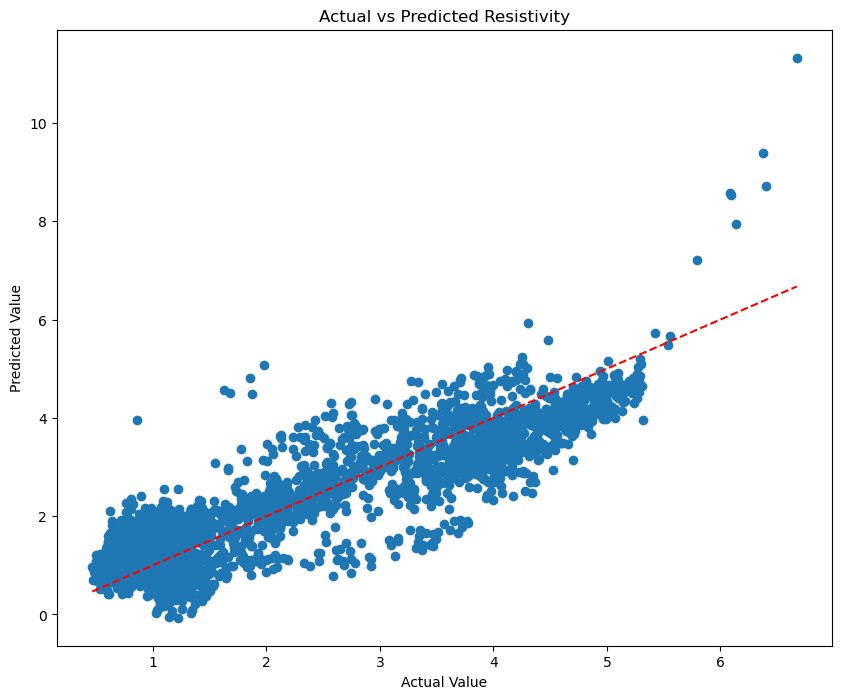

In [55]:
plt.figure(figsize = (10, 8))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "r", ls = "--")
plt.title("Actual vs Predicted Resistivity")
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.show()

*After applying a log transformation to the resistivity target, the model performance improved significantly, with R² increasing from 0.73 to 0.80.*

*The transformation reduced skewness and improved the model’s ability to learn high-resistivity values. The actual vs predicted plot shows better alignment along the diagonal, although slight underprediction at higher values remains.*

### **Save the model as pickle file**

In [57]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(model, open("best_model.pkl", "wb"))

In [58]:
print(X.columns)

Index(['CALI', 'DT', 'GR', 'LLS', 'NPHI', 'RHOB', 'DEPT'], dtype='object')
